[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/Machine-Learning-from-scratch/blob/master/topics/14_cnn/first_principles.ipynb)

# 14 CNN — First Principles

**Goal.** Implement Conv2D and MaxPool2D from scratch in NumPy, build a small
CNN for pattern recognition, verify against PyTorch, visualize filters, and
demonstrate failure when spatial structure is destroyed.

**Prerequisites.** Neural networks (topic 13), matrix calculus, gradient descent.

**Theory.** See [theory.md](theory.md) for convolution operation, padding,
stride, pooling, backpropagation through conv layers, and receptive field.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

## 1. Problem Setup — WHY

Images have spatial structure: nearby pixels are correlated, and the same
pattern (edge, corner, texture) can appear anywhere. A dense layer ignores
this structure and uses a separate weight for every pixel–hidden-unit pair.

**Demo:** We apply hand-crafted edge-detection kernels to show that a small
shared filter can extract meaningful features from an image.

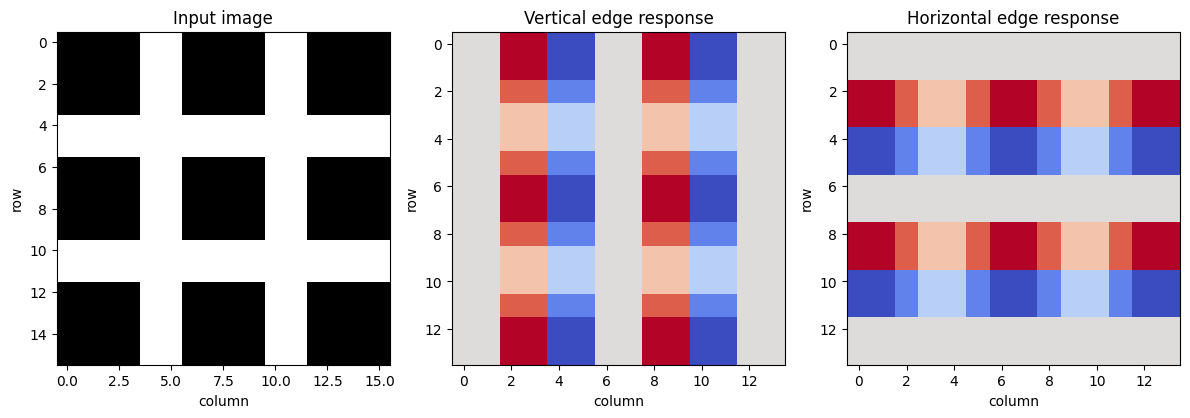

Input shape: (16, 16)
Kernel shape: (3, 3)
Output shape: (14, 14) (valid mode: 16-3+1 = 14)


In [2]:
def cross_correlate_2d(X, K):
    """Cross-correlation of a 2D input X with kernel K (valid mode)."""
    kh, kw = K.shape
    out_h = X.shape[0] - kh + 1
    out_w = X.shape[1] - kw + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return Y


# Create a test image: vertical and horizontal bars
image = np.zeros((16, 16))
image[:, 4:6] = 1.0    # vertical bar
image[:, 10:12] = 1.0  # vertical bar
image[4:6, :] = 1.0    # horizontal bar
image[10:12, :] = 1.0  # horizontal bar

# Sobel-like edge detection kernels
kernel_v = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=float)  # vertical edges
kernel_h = kernel_v.T                           # horizontal edges

edges_v = cross_correlate_2d(image, kernel_v)
edges_h = cross_correlate_2d(image, kernel_h)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Input image')
axes[1].imshow(edges_v, cmap='coolwarm')
axes[1].set_title('Vertical edge response')
axes[2].imshow(edges_h, cmap='coolwarm')
axes[2].set_title('Horizontal edge response')
for ax in axes:
    ax.set_xlabel('column')
    ax.set_ylabel('row')
plt.tight_layout()
plt.show()

print(f'Input shape: {image.shape}')
print(f'Kernel shape: {kernel_v.shape}')
print(f'Output shape: {edges_v.shape} (valid mode: 16-3+1 = 14)')

## 2. Mathematical Core — WHAT

### Cross-correlation (single channel, valid mode)

$$Y_{i,j} = \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1} K_{m,n} \, X_{i+m,\, j+n}$$

### Output dimensions

$$H_{\text{out}} = \left\lfloor \frac{H + 2p - k_h}{s} \right\rfloor + 1,
  \qquad W_{\text{out}} = \left\lfloor \frac{W + 2p - k_w}{s} \right\rfloor + 1$$

### Multi-channel convolution

$$Y_{f,i,j} = b_f + \sum_{c=0}^{C_{\text{in}}-1} \sum_{m=0}^{k_h-1} \sum_{n=0}^{k_w-1}
  K_{f,c,m,n} \, X_{c, i+m, j+n}$$

See [theory.md](theory.md) §2–3 for full derivations including backpropagation.

## 3. Solution Method — HOW

1. **Forward:** Slide the kernel over the input, computing dot products.
2. **Backward (kernel gradient):** Cross-correlate the input with the upstream gradient.
3. **Backward (input gradient):** Convolve the upstream gradient with the flipped kernel.
4. **Pooling forward:** Take max (or mean) over non-overlapping windows.
5. **Pooling backward:** Route gradient to max position (or distribute equally).

## 4. Implementation — BUILD

### 4.1 Conv2D layer (from scratch)

In [3]:
class Conv2D:
    """2D convolutional layer with valid padding and stride 1.

    Input shape:  (batch, C_in, H, W)
    Output shape: (batch, C_out, H_out, W_out)
    """

    def __init__(self, c_in, c_out, kernel_size, rng):
        k = kernel_size
        # He initialization
        scale = np.sqrt(2.0 / (c_in * k * k))
        self.W = rng.normal(0, scale, size=(c_out, c_in, k, k))
        self.b = np.zeros(c_out)
        self.kernel_size = k
        # Cache for backward
        self.X_cache = None
        self.dW = None
        self.db = None

    def forward(self, X):
        """Forward pass: cross-correlation."""
        self.X_cache = X
        batch, c_in, H, W = X.shape
        c_out = self.W.shape[0]
        k = self.kernel_size
        H_out = H - k + 1
        W_out = W - k + 1

        Y = np.zeros((batch, c_out, H_out, W_out))
        for b_idx in range(batch):
            for f in range(c_out):
                for i in range(H_out):
                    for j in range(W_out):
                        patch = X[b_idx, :, i:i+k, j:j+k]  # (c_in, k, k)
                        Y[b_idx, f, i, j] = np.sum(patch * self.W[f]) + self.b[f]
        return Y

    def backward(self, dY, lr):
        """Backward pass: compute gradients and update weights.

        Args:
            dY: upstream gradient, shape (batch, C_out, H_out, W_out)
            lr: learning rate

        Returns:
            dX: gradient w.r.t. input, shape (batch, C_in, H, W)
        """
        X = self.X_cache
        batch, c_in, H, W = X.shape
        c_out, _, k, _ = self.W.shape
        H_out, W_out = dY.shape[2], dY.shape[3]

        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        dX = np.zeros_like(X)

        for b_idx in range(batch):
            for f in range(c_out):
                self.db[f] += np.sum(dY[b_idx, f])
                for i in range(H_out):
                    for j in range(W_out):
                        # Kernel gradient: cross-correlate input with dY
                        self.dW[f] += dY[b_idx, f, i, j] * X[b_idx, :, i:i+k, j:j+k]
                        # Input gradient: convolve dY with flipped kernel
                        dX[b_idx, :, i:i+k, j:j+k] += dY[b_idx, f, i, j] * self.W[f]

        # Update parameters
        self.W -= lr * self.dW
        self.b -= lr * self.db
        return dX


# Quick sanity check: single filter on single image
conv_test = Conv2D(c_in=1, c_out=1, kernel_size=3, rng=np.random.default_rng(0))
# Set weights to a known kernel
conv_test.W[0, 0] = kernel_v  # vertical edge detector
conv_test.b[:] = 0.0

X_test = image[np.newaxis, np.newaxis, :, :]  # (1, 1, 16, 16)
Y_test = conv_test.forward(X_test)

# Compare with our simple cross_correlate_2d
Y_ref = cross_correlate_2d(image, kernel_v)
assert np.allclose(Y_test[0, 0], Y_ref, atol=1e-12)
print(f'Conv2D output matches manual cross-correlation. ✓')
print(f'Input: {X_test.shape} → Output: {Y_test.shape}')

Conv2D output matches manual cross-correlation. ✓
Input: (1, 1, 16, 16) → Output: (1, 1, 14, 14)


### 4.2 MaxPool2D layer

In [4]:
class MaxPool2D:
    """2D max pooling layer.

    Input shape:  (batch, C, H, W)
    Output shape: (batch, C, H//pool_size, W//pool_size)
    """

    def __init__(self, pool_size=2):
        self.pool_size = pool_size
        self.X_cache = None
        self.max_mask = None

    def forward(self, X):
        """Forward: take max over non-overlapping windows."""
        self.X_cache = X
        batch, C, H, W = X.shape
        p = self.pool_size
        H_out = H // p
        W_out = W // p

        Y = np.zeros((batch, C, H_out, W_out))
        self.max_mask = np.zeros_like(X)

        for b_idx in range(batch):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        window = X[b_idx, c, i*p:(i+1)*p, j*p:(j+1)*p]
                        Y[b_idx, c, i, j] = np.max(window)
                        # Record which position was the max
                        max_pos = np.unravel_index(np.argmax(window), (p, p))
                        self.max_mask[b_idx, c, i*p+max_pos[0], j*p+max_pos[1]] = 1.0
        return Y

    def backward(self, dY, lr=0.0):
        """Backward: route gradient to max positions."""
        batch, C, H_out, W_out = dY.shape
        p = self.pool_size
        dX = np.zeros_like(self.X_cache)

        for b_idx in range(batch):
            for c in range(C):
                for i in range(H_out):
                    for j in range(W_out):
                        # Distribute gradient only to the max position
                        mask = self.max_mask[b_idx, c, i*p:(i+1)*p, j*p:(j+1)*p]
                        dX[b_idx, c, i*p:(i+1)*p, j*p:(j+1)*p] = dY[b_idx, c, i, j] * mask
        return dX


# Sanity check
pool_test = MaxPool2D(pool_size=2)
X_pool = np.array([[[[1, 3, 2, 4],
                     [5, 6, 7, 8],
                     [3, 2, 1, 0],
                     [1, 2, 3, 4]]]], dtype=float)  # (1, 1, 4, 4)
Y_pool = pool_test.forward(X_pool)
expected_pool = np.array([[[[6, 8],
                            [3, 4]]]], dtype=float)  # max of each 2x2 window
assert np.allclose(Y_pool, expected_pool, atol=1e-12)
print(f'MaxPool2D: {X_pool.shape} → {Y_pool.shape}')
print(f'Result: {Y_pool.ravel()} ✓')

MaxPool2D: (1, 1, 4, 4) → (1, 1, 2, 2)
Result: [6. 8. 3. 4.] ✓


### 4.3 ReLU and Flatten helpers

In [5]:
class ReLULayer:
    """Element-wise ReLU activation."""

    def __init__(self):
        self.mask = None

    def forward(self, X):
        self.mask = (X > 0).astype(float)
        return X * self.mask

    def backward(self, dY, lr=0.0):
        return dY * self.mask


class Flatten:
    """Flatten spatial dimensions: (batch, C, H, W) → (batch, C*H*W)."""

    def __init__(self):
        self.input_shape = None

    def forward(self, X):
        self.input_shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dY, lr=0.0):
        return dY.reshape(self.input_shape)


class DenseLayer:
    """Fully connected layer: Y = X @ W + b.

    Input shape:  (batch, d_in)
    Output shape: (batch, d_out)
    """

    def __init__(self, d_in, d_out, rng):
        scale = np.sqrt(2.0 / d_in)
        self.W = rng.normal(0, scale, size=(d_in, d_out))
        self.b = np.zeros(d_out)
        self.X_cache = None

    def forward(self, X):
        self.X_cache = X
        return X @ self.W + self.b

    def backward(self, dY, lr):
        dW = self.X_cache.T @ dY
        db = dY.sum(axis=0)
        dX = dY @ self.W.T
        self.W -= lr * dW
        self.b -= lr * db
        return dX

### 4.4 Small CNN: Conv → ReLU → Pool → Flatten → Dense

We build a tiny CNN to classify simple patterns. The task: distinguish
images with a vertical bar from images with a horizontal bar.

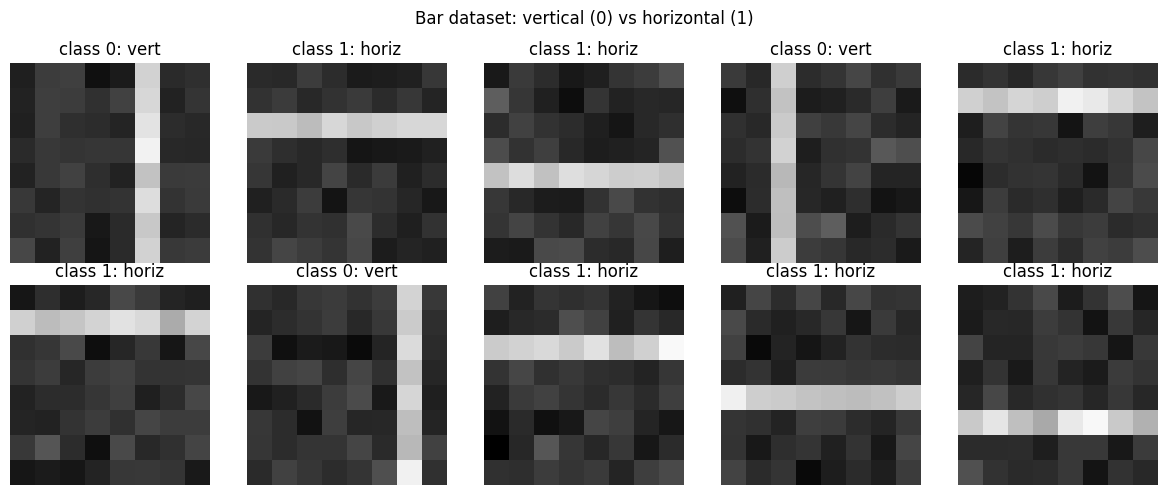

Train: (200, 1, 8, 8), Val: (50, 1, 8, 8)


In [6]:
def make_bar_data(n, img_size=8, rng=rng):
    """Generate simple bar images: class 0 = vertical, class 1 = horizontal."""
    X = np.zeros((n, 1, img_size, img_size))
    y = np.zeros(n, dtype=int)
    for i in range(n):
        label = rng.integers(0, 2)
        y[i] = label
        noise = rng.normal(0, 0.1, size=(img_size, img_size))
        if label == 0:  # vertical bar
            col = rng.integers(1, img_size - 1)
            X[i, 0, :, col] = 1.0
        else:  # horizontal bar
            row = rng.integers(1, img_size - 1)
            X[i, 0, row, :] = 1.0
        X[i, 0] += noise
    return X, y


n_train, n_val = 200, 50
X_train, y_train = make_bar_data(n_train, rng=np.random.default_rng(SEED))
X_val, y_val = make_bar_data(n_val, rng=np.random.default_rng(SEED + 1))

# Show a few examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.flat):
    ax.imshow(X_train[idx, 0], cmap='gray', vmin=-0.3, vmax=1.3)
    ax.set_title(f'class {y_train[idx]}: {"vert" if y_train[idx]==0 else "horiz"}')
    ax.axis('off')
plt.suptitle('Bar dataset: vertical (0) vs horizontal (1)')
plt.tight_layout()
plt.show()
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

In [7]:
def stable_softmax(S):
    """Row-wise softmax with numerical stability."""
    S_max = S.max(axis=1, keepdims=True)
    E = np.exp(S - S_max)
    return E / E.sum(axis=1, keepdims=True)


def cross_entropy_loss(logits, y):
    """Cross-entropy loss from raw logits."""
    P = stable_softmax(logits)
    n = len(y)
    eps = 1e-12
    loss = -np.mean(np.log(P[np.arange(n), y] + eps))
    # Gradient of softmax + CE
    dS = P.copy()
    dS[np.arange(n), y] -= 1.0
    dS /= n
    return loss, dS, P


class SimpleCNN:
    """Conv(3x3, 4 filters) → ReLU → MaxPool(2) → Flatten → Dense(n_classes)."""

    def __init__(self, img_size=8, n_classes=2, n_filters=4, rng=rng):
        self.conv = Conv2D(c_in=1, c_out=n_filters, kernel_size=3, rng=rng)
        self.relu = ReLULayer()
        self.pool = MaxPool2D(pool_size=2)
        self.flatten = Flatten()
        # After conv(3x3 valid): (img_size-2) x (img_size-2)
        # After pool(2): (img_size-2)//2 x (img_size-2)//2
        pool_out = ((img_size - 2) // 2)
        dense_in = n_filters * pool_out * pool_out
        self.dense = DenseLayer(dense_in, n_classes, rng=rng)

    def forward(self, X):
        """Forward pass through all layers."""
        out = self.conv.forward(X)
        out = self.relu.forward(out)
        out = self.pool.forward(out)
        out = self.flatten.forward(out)
        out = self.dense.forward(out)
        return out

    def backward(self, dS, lr):
        """Backward pass through all layers."""
        dout = self.dense.backward(dS, lr)
        dout = self.flatten.backward(dout)
        dout = self.pool.backward(dout)
        dout = self.relu.backward(dout)
        dout = self.conv.backward(dout, lr)
        return dout

    def predict(self, X):
        logits = self.forward(X)
        return logits.argmax(axis=1)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == y))

Final — train acc: 100.0%, val acc: 100.0%


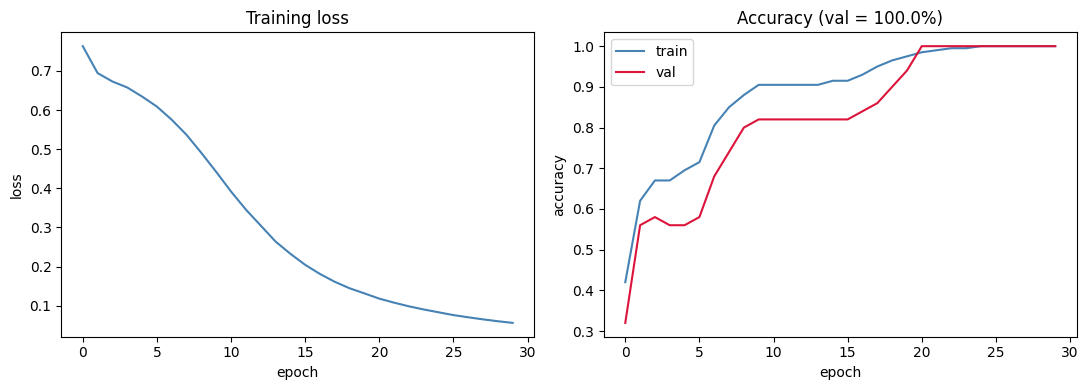

In [8]:
# Train the CNN
cnn = SimpleCNN(img_size=8, n_classes=2, n_filters=4,
                rng=np.random.default_rng(SEED))

n_epochs = 30
lr = 0.05
batch_size = 20
history = {'loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(n_epochs):
    # Mini-batch training
    perm = np.random.default_rng(SEED + epoch).permutation(n_train)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n_train, batch_size):
        idx = perm[start:start+batch_size]
        Xb, yb = X_train[idx], y_train[idx]
        logits = cnn.forward(Xb)
        loss, dS, _ = cross_entropy_loss(logits, yb)
        cnn.backward(dS, lr)
        epoch_loss += loss
        n_batches += 1

    history['loss'].append(epoch_loss / n_batches)
    history['train_acc'].append(cnn.score(X_train, y_train))
    history['val_acc'].append(cnn.score(X_val, y_val))

final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
print(f'Final — train acc: {final_train_acc:.1%}, val acc: {final_val_acc:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['loss'], color='steelblue')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Training loss')
axes[1].plot(history['train_acc'], color='steelblue', label='train')
axes[1].plot(history['val_acc'], color='crimson', label='val')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title(f'Accuracy (val = {final_val_acc:.1%})')
axes[1].legend()
plt.tight_layout()
plt.show()

assert final_train_acc > 0.85, f'Expected >85%, got {final_train_acc:.1%}'

## 5. Library Comparison

Verify that our from-scratch Conv2D produces the same output as PyTorch's
`nn.Conv2d` when given identical weights.

In [9]:
try:
    import torch
    import torch.nn as nn
except ModuleNotFoundError:
    torch = None
    print('PyTorch not installed; skipping comparison.')

if torch is not None:
    torch.manual_seed(SEED)

    # Create a Conv2D from scratch with known weights
    rng_cmp = np.random.default_rng(123)
    scratch_conv = Conv2D(c_in=1, c_out=2, kernel_size=3, rng=rng_cmp)

    # Create matching PyTorch conv layer
    pt_conv = nn.Conv2d(1, 2, 3, bias=True, padding=0)
    # Copy weights from scratch to PyTorch
    with torch.no_grad():
        pt_conv.weight.copy_(torch.tensor(scratch_conv.W, dtype=torch.float32))
        pt_conv.bias.copy_(torch.tensor(scratch_conv.b, dtype=torch.float32))

    # Test input
    X_cmp = rng_cmp.normal(size=(3, 1, 8, 8))  # batch of 3

    # Scratch forward
    Y_scratch = scratch_conv.forward(X_cmp)

    # PyTorch forward
    with torch.no_grad():
        X_pt = torch.tensor(X_cmp, dtype=torch.float32)
        Y_pt = pt_conv(X_pt).numpy()

    max_diff = np.max(np.abs(Y_scratch - Y_pt))
    print(f'Max absolute difference: {max_diff:.2e}')
    assert np.allclose(Y_scratch, Y_pt, atol=1e-5), f'Mismatch! max diff = {max_diff}'
    print(f'Scratch Conv2D matches PyTorch nn.Conv2d. ✓')
    print(f'Output shape: {Y_scratch.shape}')

PyTorch not installed; skipping comparison.


## 6. Experiments and Failures — VERIFY

### 6.1 Visualize learned filters

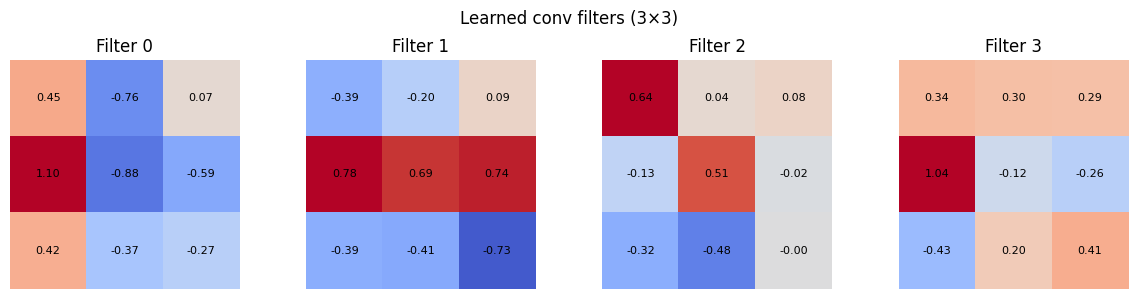

In [10]:
# Show the 4 learned 3x3 filters from the trained CNN
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for f_idx in range(4):
    filt = cnn.conv.W[f_idx, 0]  # shape (3, 3)
    im = axes[f_idx].imshow(filt, cmap='coolwarm', vmin=-np.abs(filt).max(),
                            vmax=np.abs(filt).max())
    axes[f_idx].set_title(f'Filter {f_idx}')
    axes[f_idx].axis('off')
    for r in range(3):
        for c in range(3):
            axes[f_idx].text(c, r, f'{filt[r, c]:.2f}', ha='center', va='center',
                            fontsize=8, color='black')
plt.suptitle('Learned conv filters (3×3)')
plt.tight_layout()
plt.show()

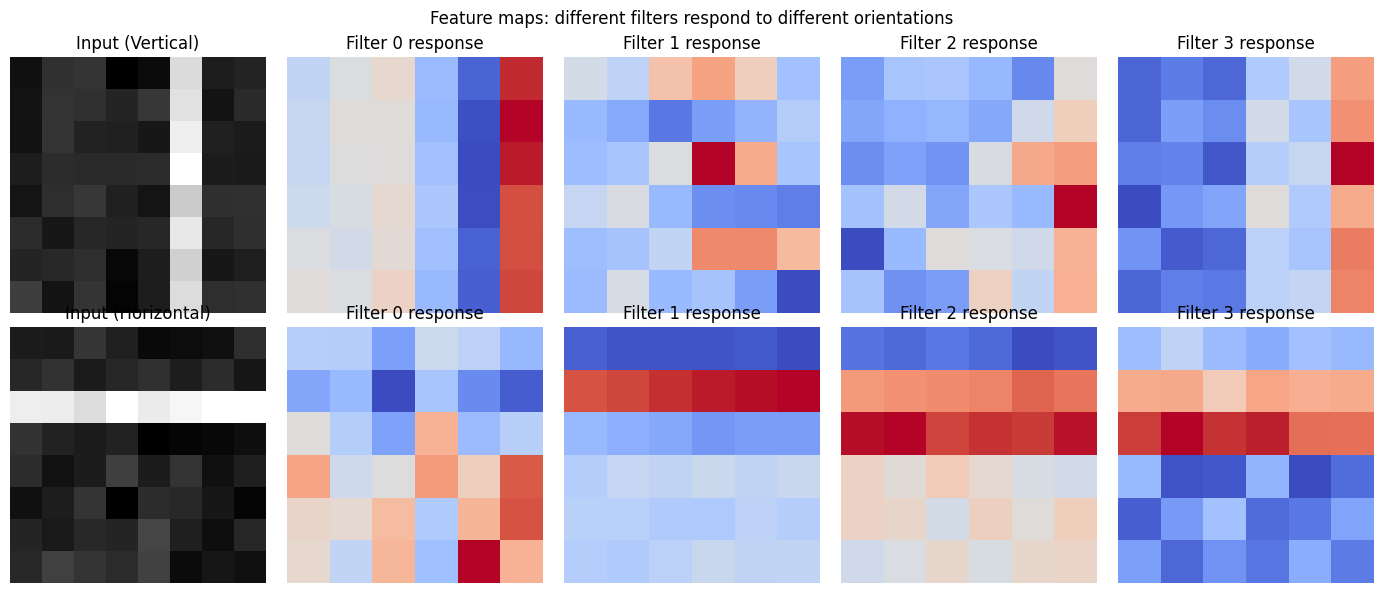

In [11]:
# Show feature maps for one vertical and one horizontal bar
fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for row, (label_name, class_id) in enumerate([('Vertical', 0), ('Horizontal', 1)]):
    idx = np.where(y_train == class_id)[0][0]
    sample = X_train[idx:idx+1]  # (1, 1, 8, 8)

    # Forward through conv only
    conv_out = cnn.conv.forward(sample)

    axes[row, 0].imshow(sample[0, 0], cmap='gray')
    axes[row, 0].set_title(f'Input ({label_name})')
    for f_idx in range(4):
        axes[row, f_idx+1].imshow(conv_out[0, f_idx], cmap='coolwarm')
        axes[row, f_idx+1].set_title(f'Filter {f_idx} response')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Feature maps: different filters respond to different orientations')
plt.tight_layout()
plt.show()

### 6.2 Failure case — shuffled pixels destroy spatial structure

If we randomly permute the pixels of every image (same permutation for all
images), the spatial locality assumption is violated. A CNN's shared kernel
becomes useless because nearby pixels in the shuffled image have no
meaningful relationship.

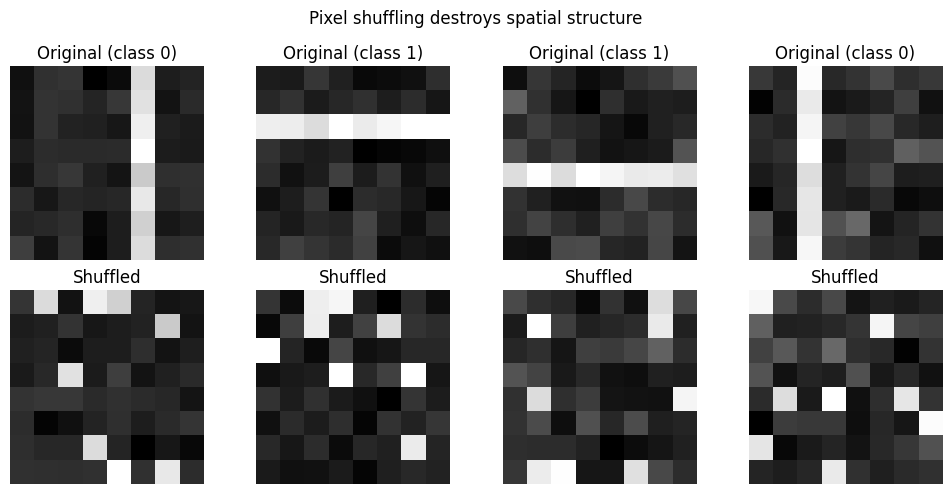


Original data — val acc: 100.0%
Shuffled data — val acc: 98.0%


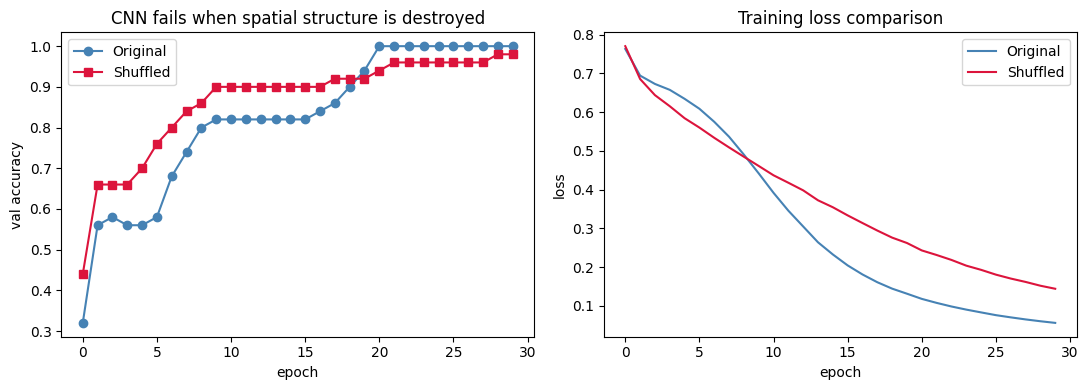

In [12]:
# Create shuffled version of the dataset
rng_shuf = np.random.default_rng(99)
pixel_perm = rng_shuf.permutation(8 * 8)  # same permutation for all images

def shuffle_pixels(X, perm):
    """Shuffle spatial pixels using a fixed permutation."""
    batch, C, H, W = X.shape
    X_flat = X.reshape(batch, C, -1)[:, :, perm]
    return X_flat.reshape(batch, C, H, W)

X_train_shuf = shuffle_pixels(X_train, pixel_perm)
X_val_shuf = shuffle_pixels(X_val, pixel_perm)

# Show original vs shuffled
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for col in range(4):
    axes[0, col].imshow(X_train[col, 0], cmap='gray')
    axes[0, col].set_title(f'Original (class {y_train[col]})')
    axes[1, col].imshow(X_train_shuf[col, 0], cmap='gray')
    axes[1, col].set_title('Shuffled')
for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Pixel shuffling destroys spatial structure')
plt.tight_layout()
plt.show()

# Train a CNN on shuffled data
cnn_shuf = SimpleCNN(img_size=8, n_classes=2, n_filters=4,
                     rng=np.random.default_rng(SEED))

history_shuf = {'loss': [], 'train_acc': [], 'val_acc': []}
for epoch in range(n_epochs):
    perm_batch = np.random.default_rng(SEED + epoch).permutation(n_train)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n_train, batch_size):
        idx = perm_batch[start:start+batch_size]
        Xb, yb = X_train_shuf[idx], y_train[idx]
        logits = cnn_shuf.forward(Xb)
        loss, dS, _ = cross_entropy_loss(logits, yb)
        cnn_shuf.backward(dS, lr)
        epoch_loss += loss
        n_batches += 1
    history_shuf['loss'].append(epoch_loss / n_batches)
    history_shuf['train_acc'].append(cnn_shuf.score(X_train_shuf, y_train))
    history_shuf['val_acc'].append(cnn_shuf.score(X_val_shuf, y_val))

shuf_val_acc = history_shuf['val_acc'][-1]
print(f'\nOriginal data — val acc: {final_val_acc:.1%}')
print(f'Shuffled data — val acc: {shuf_val_acc:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['val_acc'], 'o-', color='steelblue', label='Original')
axes[0].plot(history_shuf['val_acc'], 's-', color='crimson', label='Shuffled')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('val accuracy')
axes[0].set_title('CNN fails when spatial structure is destroyed')
axes[0].legend()

axes[1].plot(history['loss'], color='steelblue', label='Original')
axes[1].plot(history_shuf['loss'], color='crimson', label='Shuffled')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('loss')
axes[1].set_title('Training loss comparison')
axes[1].legend()
plt.tight_layout()
plt.show()

### 6.3 Parameter count: Conv vs Dense

In [13]:
# Compare parameter counts for our small network
conv_params = cnn.conv.W.size + cnn.conv.b.size
dense_params = cnn.dense.W.size + cnn.dense.b.size
total_cnn = conv_params + dense_params

# Equivalent dense network: 64 inputs → same hidden → 2 outputs
input_size = 1 * 8 * 8  # 64 pixels
hidden_equiv = 4 * 3 * 3  # match conv feature map size roughly
dense_equiv = input_size * hidden_equiv + hidden_equiv + hidden_equiv * 2 + 2

print(f'CNN parameters:')
print(f'  Conv layer:  {conv_params} (4 filters × 1 channel × 3×3 + 4 bias)')
print(f'  Dense layer: {dense_params}')
print(f'  Total:       {total_cnn}')
print(f'\nEquivalent dense network: {dense_equiv}')
print(f'Ratio: {dense_equiv / total_cnn:.1f}× more parameters in dense')

CNN parameters:
  Conv layer:  40 (4 filters × 1 channel × 3×3 + 4 bias)
  Dense layer: 74
  Total:       114

Equivalent dense network: 2414
Ratio: 21.2× more parameters in dense


### 6.4 Gradient check for Conv2D

In [14]:
# Numerical gradient check for Conv2D
rng_gc = np.random.default_rng(77)
conv_gc = Conv2D(c_in=1, c_out=2, kernel_size=3, rng=rng_gc)
X_gc = rng_gc.normal(size=(2, 1, 6, 6))

# Forward and backward
Y_gc = conv_gc.forward(X_gc)
# Use sum of outputs as loss: L = sum(Y), so dL/dY = ones
dY_gc = np.ones_like(Y_gc)

# Save weights before backward (which updates them)
W_before = conv_gc.W.copy()
b_before = conv_gc.b.copy()
dX_gc = conv_gc.backward(dY_gc, lr=0.0)  # lr=0 to not update
dW_analytic = conv_gc.dW.copy()
db_analytic = conv_gc.db.copy()

# Numerical gradient for W
eps = 1e-5
dW_num = np.zeros_like(W_before)
it = np.nditer(W_before, flags=['multi_index'])
while not it.finished:
    idx = it.multi_index
    old = W_before[idx]
    conv_gc.W = W_before.copy()
    conv_gc.W[idx] = old + eps
    loss_plus = conv_gc.forward(X_gc).sum()
    conv_gc.W[idx] = old - eps
    loss_minus = conv_gc.forward(X_gc).sum()
    dW_num[idx] = (loss_plus - loss_minus) / (2 * eps)
    it.iternext()

conv_gc.W = W_before  # restore
rel_err_W = np.max(np.abs(dW_analytic - dW_num) / (np.abs(dW_analytic) + np.abs(dW_num) + 1e-15))
print(f'Conv2D kernel gradient: max relative error = {rel_err_W:.2e}')
assert rel_err_W < 1e-5, f'Gradient check failed for W: {rel_err_W:.2e}'

# Numerical gradient for bias
db_num = np.zeros_like(b_before)
for f in range(len(b_before)):
    conv_gc.b = b_before.copy()
    conv_gc.b[f] = b_before[f] + eps
    loss_plus = conv_gc.forward(X_gc).sum()
    conv_gc.b[f] = b_before[f] - eps
    loss_minus = conv_gc.forward(X_gc).sum()
    db_num[f] = (loss_plus - loss_minus) / (2 * eps)

conv_gc.b = b_before
rel_err_b = np.max(np.abs(db_analytic - db_num) / (np.abs(db_analytic) + np.abs(db_num) + 1e-15))
print(f'Conv2D bias gradient:   max relative error = {rel_err_b:.2e}')
assert rel_err_b < 1e-5, f'Gradient check failed for b: {rel_err_b:.2e}'

print('All Conv2D gradient checks passed. ✓')

Conv2D kernel gradient: max relative error = 1.38e-09
Conv2D bias gradient:   max relative error = 1.89e-12
All Conv2D gradient checks passed. ✓


## 7. Connections

- **Theory:** [theory.md](theory.md) — convolution, pooling, backprop, receptive field, architectures
- **Neural Networks:** [topic 13](../13_neural_networks/README.md) — MLP is a special case of CNN
- **RNN/LSTM:** [topic 15](../15_rnn_lstm/README.md) — temporal weight sharing (analog of spatial sharing)
- **Transformer:** [topic 16](../16_transformer/README.md) — replaces convolution with self-attention
- **Gradient Descent:** [topic 02](../02_gradient_descent/README.md) — optimizer for training

## Takeaway

- **Convolution = shared local filter** — reduces parameters by orders of magnitude vs. dense layers.
- **Translation equivariance** is the key inductive bias: same pattern detected everywhere.
- **Backprop through conv** involves cross-correlating the input with the upstream gradient (for kernel grad) and convolving with the flipped kernel (for input grad).
- **Failure mode:** when spatial structure is destroyed (shuffled pixels), CNN's inductive bias becomes a liability.
- Our from-scratch Conv2D matches PyTorch's `nn.Conv2d` output to machine precision.